# I. Intorductions


This chapter explores how machine learning (ML) can be applied to networks, particularly **friendship networks**, by leveraging both **network structure** and **individual metadata**. While traditional network analysis tools are useful for understanding structure and spread, ML provides a way to enrich this analysis by incorporating additional information about individuals and their connections.

Key topics covered include:

* **Network construction** using shared activities and traits.
* **Clustering** based on a combination of network metrics and metadata.
* **Prediction of outcomes** (e.g., individual attributes or connection strength) using ML models.
* Integration of **network features** with **ML models** to provide deeper insights.
* Applications of **standard ML** and **semi-supervised deep learning (SDL)** techniques on relational data.

The chapter sets the foundation for applying ML to networks, preparing readers for more advanced topics in later chapters.

---

In this notebook, we explore a **friendship network** of 25 high school students, based on shared activities such as sports teams, study groups, elective classes, and neighborhood ties. The data, originally derived from a student diary (Farrelly, student #7), captures both **strong social ties** (e.g., close friendships formed through frequent interactions) and **weak ties** (e.g., casual connections through shared classes).

Strong ties often influence personal development and behavior, while weak ties play a key role in spreading new ideas and connecting different social groups. Understanding both types of relationships helps us model how information, behaviors, or even illnesses might spread through a student network.

We'll begin by building a **weighted social graph** where connections are based on shared activities. Using **unsupervised learning**, we'll cluster students into likely friendship groups. Later, we’ll apply **graph-based supervised learning** methods such as **Graph Neural Networks (GNNs)** to assess social network risks, including potential epidemic spread patterns.

This notebook combines **network analysis**, **metadata exploration**, and **machine learning** to better understand the dynamics of adolescent social structures.



# II. Classical Machine learning techniques

## 1. Import Functions

In [115]:
#import packages needed
import pandas as pd
from sklearn.cluster import KMeans
import igraph as ig
from igraph import Graph
import numpy as np
import os
import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
import networkx as nx
import json

## 2. Pure K-means Clustering 

In [2]:
#import file
File ="/home/sako/Data science lessons/Graph Theory/Book Course (Python with Network science)/git_directory/graph_network_data_science/data/Friendship_Factors.csv"
mydata =pd.read_csv(File,encoding='latin1')

In [3]:
#k-means model
X=mydata[mydata.columns.drop('Individual ID')]
km=KMeans(n_clusters=3,init='random',n_init=5,random_state=5)
km_model=km.fit_predict(X)

#explore k-means model
km_model

array([2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1,
       0, 0, 0], dtype=int32)

In [4]:
#add to dataset as first solution
km_1=np.array(km_model)+1
mydata['km_1']=km_1

#### Cluster 1

In [5]:
mydata.sort_values('Individual ID').query("km_1==1")

,Individual ID,Current Teammates,Workout Together,Weekend Sports,Attended Game,Homework Together,Class 1,Class 2,Class 3,Class 4,km_1
7,8,1,0,0,1,0,0,1,0,1,1
8,9,1,0,0,1,0,0,1,0,0,1
11,12,1,0,0,0,0,0,1,0,0,1
12,13,0,0,0,0,0,1,1,0,0,1
15,16,1,0,0,0,0,0,1,0,0,1
22,23,1,0,0,0,0,0,1,0,0,1
23,24,0,0,0,0,0,0,1,0,0,1
24,25,0,0,0,0,0,0,1,0,0,1


Cluster characteristics:
- Current teamates
- They don't share workouts or weekend sports
- Don't do homework together
- take some similar classes
- They just take Class 2 togther

Thet seem to be of low risk for sort of a pandemic due to their lack of involvement

#### Cluster 2

In [6]:
mydata.sort_values('Individual ID').query("km_1==2")

,Individual ID,Current Teammates,Workout Together,Weekend Sports,Attended Game,Homework Together,Class 1,Class 2,Class 3,Class 4,km_1
10,11,0,0,0,0,0,1,0,0,0,2
13,14,1,0,0,1,0,1,0,0,0,2
14,15,1,0,0,0,0,1,0,0,1,2
16,17,1,0,0,0,0,0,0,1,0,2
17,18,0,0,0,0,0,1,0,0,0,2
19,20,0,0,0,0,0,0,0,1,0,2
20,21,0,0,0,0,1,0,0,1,1,2
21,22,1,0,0,0,0,0,0,0,0,2


Cluster characteristics:
- Seems like a mix of low activity combinations

Thet seem to be of low risk for sort of a pandemic due to their lack of involvement

#### Cluster 3

In [7]:
mydata.sort_values('Individual ID').query("km_1==3")

,Individual ID,Current Teammates,Workout Together,Weekend Sports,Attended Game,Homework Together,Class 1,Class 2,Class 3,Class 4,km_1
0,1,1,1,0,1,1,1,0,0,1,3
1,2,1,1,1,1,1,1,1,1,0,3
2,3,1,1,1,1,1,1,0,1,0,3
3,4,1,1,1,1,1,0,1,0,1,3
4,5,1,1,0,1,1,0,1,0,1,3
5,6,0,1,0,1,1,0,0,1,0,3
6,7,0,1,1,1,1,0,0,1,1,3
9,10,1,0,0,1,1,0,0,1,1,3
18,19,1,0,0,1,1,1,1,0,0,3


Cluster characteristics:
- Current teamates
- Workout together
- to sports 
- take some similar classes
- They do homeworks together 

Thet seem to be of high risk for sort of a pandemic due to their lack of involvement

## 3. Clustering using network techniques

### A. Using the pearson correlation we estimate the relationships between students

Text(0, 0.5, 'Frequency')

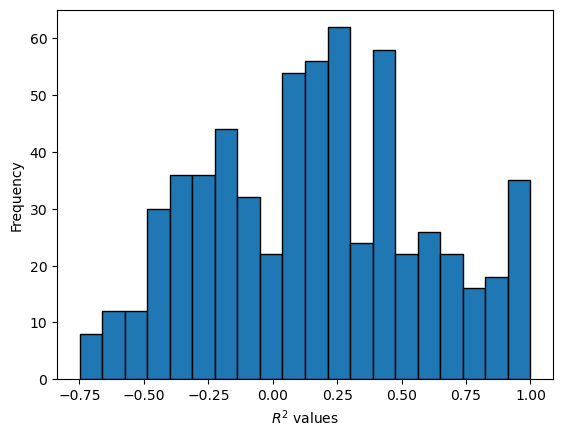

In [27]:
#create network via Pearson correlation
plt.hist(np.corrcoef(X).flatten(),edgecolor='black',bins=20)
plt.xlabel("$R^2$ values")
plt.ylabel("Frequency")


**Visual the relationship for $R^2$ ~ 0.5**

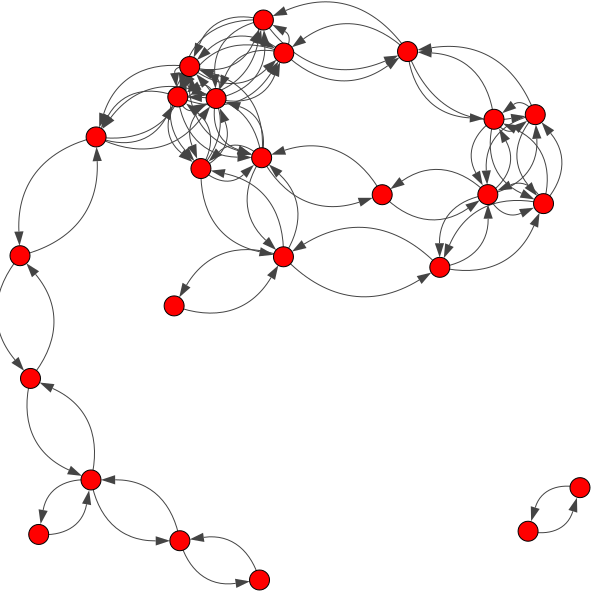

In [9]:
#create network via Pearson correlation
cor=np.corrcoef(X)
cor[cor>=0.5]=1
cor[cor<0.5]=0
X2=np.asmatrix(cor)

#create graph with self-loops removed
friends=Graph.Adjacency(X2)
edge_list=friends.get_edgelist()
self_loop=[]
for i in range(0,25):
    self=(i,i)
    self_loop.append(self)
    
to_remove=[]
for i in edge_list:
    for j in self_loop:
        if i==j:
            to_remove.append(i)

friends.delete_edges(to_remove)

layout = friends.layout("fr")
ig.plot(friends,layout=layout)

### B. Using additional network metrics to do K-means

In [20]:
#create scaled metrics and attach to X
d=np.array(Graph.degree(friends))/10
p=np.array(Graph.pagerank(friends))*20
X.loc[:,'degree']=d
X.loc[:,'pagerank']=p

#create new k-means model with graph metrics added
km2=KMeans(n_clusters=3,init='random',n_init=5,random_state=5)
km_model2=km2.fit_predict(X)

#explore new k-means model
km_model2
#add to dataset as first solution
km_2=np.array(km_model2)+1
mydata.loc[:,'km_2'] = km_2

### C. Implement Spectral clustering using Sklearn

In [29]:
#import packages needed
from sklearn.cluster import SpectralClustering
from sklearn import metrics #perform spectral clustering and attach to dataset
sc = SpectralClustering(3, affinity='precomputed',n_init=5)
sp_clust=sc.fit(cor)
mydata['sp']=sp_clust.labels_

/home/sako/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


## 4. Visualize clustering results on top of network 

In [164]:
mydata.sort_values("km_1").groupby("km_1").nunique()[['km_2','sp']]

,km_2,sp
km_1,,
1,2,1
2,2,2
3,1,3


**Note that the cluster migration might different from that othe book**. The data is so small and the algorithm doesn't always convert in the same way. The book has not supplied with a radom seed. I have used it hence if you rerun the code you will get the same result. 

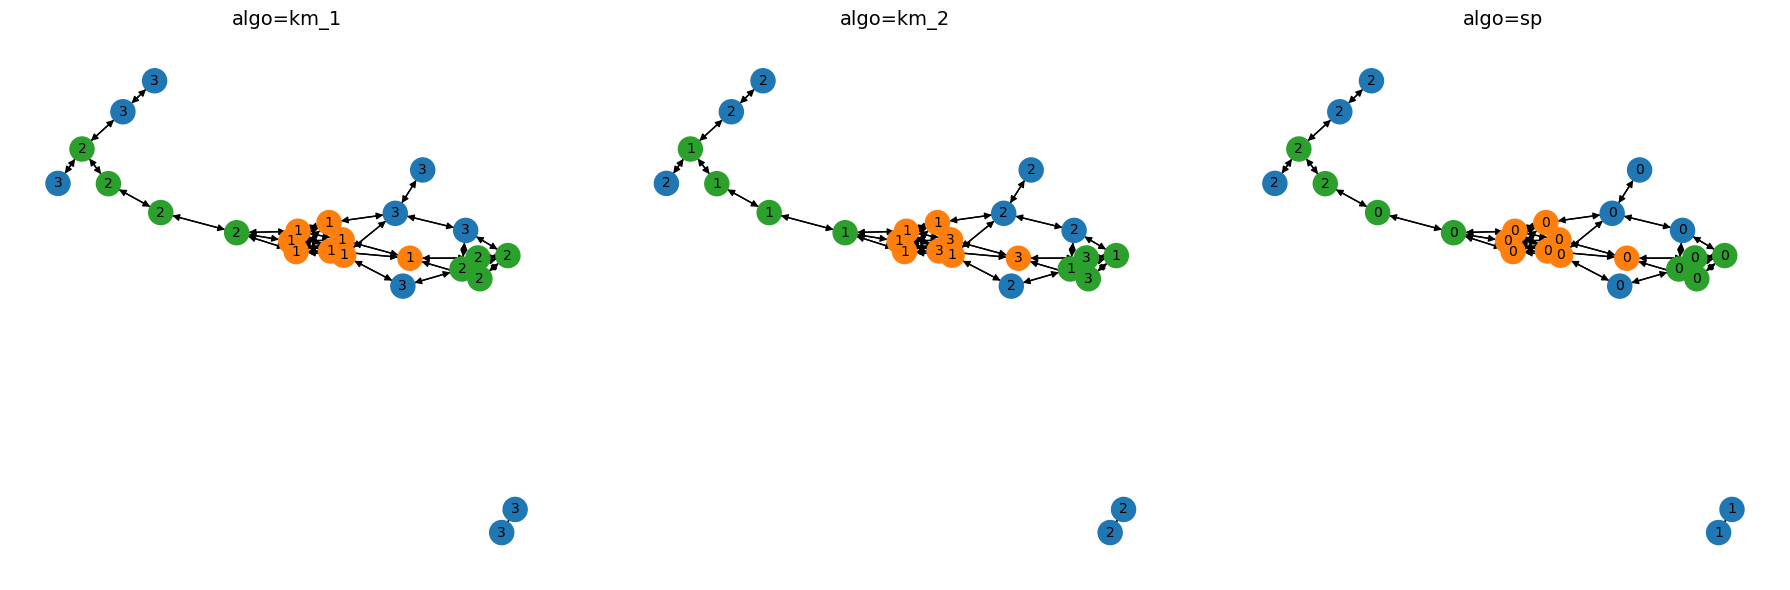

In [171]:
# Convert igraph to networkx (undirected) and save layout
G_nx = friends.to_networkx()
pos = nx.spring_layout(G_nx,seed=42)
serializable_pos = {str(k): v.tolist() for k, v in pos.items()}
with open("./data/layout.json", "w") as f:
    json.dump(serializable_pos, f)

# Load layout
with open("./data/layout.json", "r") as f:
    pos = {int(k): v for k, v in json.load(f).items()}



# Generate distinct colors for each cluster
clusters = mydata['km_1'].unique()
colors = list(mcolors.TABLEAU_COLORS.values())[0:clusters.shape[0]]  # or use mcolors.CSS4_COLORS
colors_map = {val:colors[idx] for idx,val in enumerate(clusters)  }
vertex_colors = mydata['km_1'].replace(colors_map).tolist()

# Create 4x3 subplots (12 total)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

# Convert igraph to networkx (undirected)
G_nx = friends.to_networkx()


# Plot
for idx,val in enumerate(['km_1','km_2','sp']):
    labels = {idx:i for idx,i in enumerate(mydata[val])}
    nx.draw(G_nx,
            ax=axes[idx], 
            pos = pos, 
            with_labels=True,
            labels=labels,
            node_color=vertex_colors,
        node_size=300, font_size=10)
    
    axes[idx].set_title(f"algo={val}", fontsize=14)

# Hide the remaining unused axes
for j in range(3, len(axes)):
    axes[j].set_visible(False)

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

#### Conclusions

* **Spectral clustering** relies only on **network connectivity** (derived from correlations).
* **K-means** considers **individual-level features** like activities and schedules.
* A **hybrid approach** (e.g., k-means with network metrics) may be more appropriate for such data.

#### Key Points:

* Spectral clustering is useful for **pure network-based problems** or when **node attributes are missing**.
* It also supports **semi-supervised learning (SSL)** when partial labels are available.
* For **large networks**, k-means (with scalable features) is often more **efficient** and **interpretable**.



# II. Deep Learning